# **Aprendizaje por refuerzos** - FrozenLake y LunarLander (Gymnasium)

## Tarea: Implementar Agentes Q-Learning y DQN

### Objetivos:
1. Implementar el algoritmo Q-Learning
2. Implementar el algoritmo DQN
3. Entrenar y evaluar ambos agentes
4. Comparar el rendimiento de ambos enfoques


In [ ]:
# Instalar paquetes requeridos
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

%pip install swig matplotlib gymnasium torch pygame

In [ ]:
# Importar las bibliotecas
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pygame
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque, namedtuple
import random


La siguiente celda permite ejecutar un juego de Frozen Lake *determinista* para jugar con el teclado.

Utilize las teclas de dirección (flechas) o asdw para comandar al agente.


In [2]:
def jugar_frozen_lake(env):
    env.reset()
    
    print("Controles:")
    print("W - Arriba")
    print("S - Abajo") 
    print("A - Izquierda")
    print("D - Derecha")
    print("Q - Salir")
    print("Presione cualquier tecla para empezar...")
    
    pygame.init()
    pygame.display.set_caption("FrozenLake - Juego Interactivo")
    
    clock = pygame.time.Clock()
    ejecutando = True
    
    while ejecutando:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                ejecutando = False
            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_q or event.key == pygame.K_ESCAPE:
                    ejecutando = False
                elif event.key == pygame.K_w or event.key == pygame.K_UP:
                    accion = 3  # Arriba
                elif event.key == pygame.K_s or event.key == pygame.K_DOWN:
                    accion = 1  # Abajo
                elif event.key == pygame.K_a or event.key == pygame.K_LEFT:
                    accion = 0  # Izquierda
                elif event.key == pygame.K_d or event.key == pygame.K_RIGHT:
                    accion = 2  # Derecha
                else:
                    continue
                
                observacion, recompensa, terminado, truncado, info = env.step(accion)
                print(f"Acción: {accion}, Recompensa: {recompensa}, Terminado: {terminado}")
                
                if terminado or truncado:
                    print(f"¡Episodio terminado! Recompensa final: {recompensa}")
                    pygame.time.wait(500)
                    env.reset()
        
        clock.tick(60)
    
    pygame.quit()
    env.close()

env = gym.make('FrozenLake-v1', render_mode='human', is_slippery=False)
# Descomente la línea de abajo para jugar interactivamente
# jugar_frozen_lake(env)


La siguiente celda permite jugar al juego no determinista.

In [3]:
env = gym.make('FrozenLake-v1', render_mode='human', is_slippery=True)
# Descomente la línea de abajo para jugar interactivamente
# jugar_frozen_lake(env)

La siguiente clase define la interfaz de los agentes que utilizaremos para jugar al Frozen Lake.


In [4]:
from abc import ABC, abstractmethod

class Agente(ABC):
    
    @abstractmethod
    def elegir_accion(self, estado):
        """Elige una acción dada una observación."""
        pass
    
    @abstractmethod
    def aprender(self, estado, accion, recompensa, siguiente_estado, terminado):
        """Aprende de la experiencia."""
        pass

class AgenteAleatorio(Agente):
    """Agente aleatorio que elige acciones al azar."""
    
    def __init__(self, espacio_acciones):
        # Se guarda el espacio de acciones para poder elegir acciones al azar
        self.espacio_acciones = espacio_acciones
    
    def elegir_accion(self, estado):
        return self.espacio_acciones.sample()
    
    def aprender(self, estado, accion, recompensa, siguiente_estado, terminado):
        pass  # El agente aleatorio no aprende

# Probar el AgenteAleatorio
env = gym.make('FrozenLake-v1')
agente_aleatorio = AgenteAleatorio(env.action_space)
estado, _ = env.reset()
accion = agente_aleatorio.elegir_accion(estado)
print(f"✓ AgenteAleatorio creado y probado. Acción: {accion}")
env.close()


✓ AgenteAleatorio creado y probado. Acción: 2


La siguiente celda define una función para evaluar el desempeño de un agente dado.

In [5]:
# Función de Evaluación de Agentes
def evaluar_agente(agente, env, num_episodios=1000):
    """
    Evalúa el rendimiento de un agente a lo largo de múltiples episodios.
    
    Args:
        agente: El agente a evaluar
        env: El entorno
        num_episodios: Número de episodios a ejecutar
    
    Returns:
        dict: Resultados de la evaluación
    """
    recompensas_totales = []
    victorias = 0
    
    for episodio in range(num_episodios):
        estado, _ = env.reset()
        recompensa_total = 0
        
        while True:
            accion = agente.elegir_accion(estado)
            estado, recompensa, terminado, truncado, _ = env.step(accion)
            recompensa_total += recompensa
            
            if terminado or truncado:
                break
        
        recompensas_totales.append(recompensa_total)
        if recompensa_total > 0:
            victorias += 1
    
    return {
        'recompensas_totales': recompensas_totales,
        'victorias': victorias,
        'tasa_victorias': victorias / num_episodios,
        'recompensa_promedio': np.mean(recompensas_totales),
        'desv_estandar': np.std(recompensas_totales)
    }

def imprimir_resultados_evaluacion(resultados, nombre_agente):
    """Imprime los resultados de evaluación de forma formateada."""
    print(f"\n{nombre_agente} - Resultados de Evaluación:")
    print(f"Tasa de Victorias: {resultados['tasa_victorias']:.1%}")
    print(f"Recompensa Promedio: {resultados['recompensa_promedio']:.3f}")
    print(f"Desviación Estándar: {resultados['desv_estandar']:.3f}")
    print(f"Total de Victorias: {resultados['victorias']}")

# Probar función de evaluación
env = gym.make('FrozenLake-v1')
agente_aleatorio = AgenteAleatorio(env.action_space)
resultados = evaluar_agente(agente_aleatorio, env, num_episodios=100)
imprimir_resultados_evaluacion(resultados, "Agente Aleatorio")
env.close()



Agente Aleatorio - Resultados de Evaluación:
Tasa de Victorias: 0.0%
Recompensa Promedio: 0.000
Desviación Estándar: 0.000
Total de Victorias: 0


La siguiente celda define una función para entrenar un agente.

In [6]:
# Función de Entrenamiento de Agentes
def entrenar_agente(agente, env, num_episodios=1000, max_pasos=100, verbose=True):
    """
    Entrena un agente en el entorno.
    
    Args:
        agente: El agente a entrenar
        env: El entorno
        num_episodios: Número de episodios de entrenamiento
        max_pasos: Máximo de pasos por episodio
        verbose: Si imprimir el progreso
    
    Returns:
        list: Recompensas de episodios
    """
    recompensas_episodios = []
    longitudes_episodios = []
    num_episodios_10 = int(num_episodios / 10)
    
    for episodio in range(num_episodios):
        estado, _ = env.reset()
        recompensa_total = 0
        pasos = 0
        
        for paso in range(max_pasos):
            accion = agente.elegir_accion(estado)
            siguiente_estado, recompensa, terminado, truncado, _ = env.step(accion)
            
            agente.aprender(estado, accion, recompensa, siguiente_estado, terminado or truncado)
            
            estado = siguiente_estado
            recompensa_total += recompensa
            pasos += 1
            
            if terminado or truncado:
                break
        
        recompensas_episodios.append(recompensa_total)
        longitudes_episodios.append(pasos)
        
        if verbose and (episodio + 1) % num_episodios_10 == 0:
            recompensa_promedio = np.mean(recompensas_episodios[-num_episodios_10:])
            longitud_promedio = np.mean(longitudes_episodios[-num_episodios_10:])
            print(f"Episodio {episodio + 1}: Recompensa Promedio = {recompensa_promedio:.3f}, Longitud Promedio = {longitud_promedio:.1f}")
    
    return recompensas_episodios, longitudes_episodios

print("✓ Funciones de entrenamiento definidas")


✓ Funciones de entrenamiento definidas


## 1. **Agente Q-Learning**
La siguiente celda define el agente de Q-Learning a implementar.

In [7]:
class AgenteQLearning(Agente):
    """Agente que usa el algoritmo Q-Learning."""
    
    def __init__(self, espacio_observacion, espacio_acciones, alpha_offset=25, alpha_min=0.03,
                 gamma=0.99, epsilon=1, epsilon_decay=0.000015, epsilon_min=0.01):
        """
        Inicializa el agente Q-Learning.

        Args:
            espacio_observacion (int): Número de estados posibles.
            espacio_acciones (int): Número de acciones posibles.
            alpha_offset (float): Offset para el cálculo de alpha dinámico.
            alpha_min (float): Valor mínimo de alpha.
            gamma (float): Factor de descuento.
            epsilon (float): Probabilidad inicial de exploración (epsilon-greedy).
            epsilon_decay (float): Cantidad fija a disminuir epsilon por episodio.
            epsilon_min (float): Valor mínimo que puede tomar epsilon en el entrenamiento.
        """
        self.n = int(np.sqrt(espacio_observacion))
        self.qtable = np.zeros((espacio_observacion, espacio_acciones)) 
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.espacio_acciones = espacio_acciones
        # Para α dinámico
        self.visitas = np.zeros_like(self.qtable, dtype=np.int64)
        self.alpha_offset = alpha_offset
        self.alpha_min = alpha_min
    
    def elegir_accion(self, estado):
        """Elige una acción usando política epsilon-greedy."""
        if random.uniform(0, 1) < self.epsilon:
            # Exploración: elige una acción aleatoria
            return random.randint(0, self.espacio_acciones - 1)
        else:
            # Explotación: elige la acción con el valor Q más alto para el estado actual
            return np.argmax(self.qtable[estado, :])
    
    def aprender(self, estado, accion, recompensa, siguiente_estado, terminado):
        """Actualiza la tabla Q usando alpha dinámico basado en visitas."""
        # Actualizamos epsilon en cada paso
        self.epsilon = max(self.epsilon_min, self.epsilon - self.epsilon_decay)

        # Incrementar contador de visitas
        self.visitas[estado, accion] += 1
        # Calcular α dinámico: α(s,a) = max(α_min, 1/(offset + visitas))
        alpha_sa = max(self.alpha_min, 1.0 / (self.alpha_offset + self.visitas[estado, accion]))
        # Calcular target de TD
        if terminado:
            td_target = recompensa
        else:
            td_target = recompensa + self.gamma * np.max(self.qtable[siguiente_estado, :])
        # Actualizar Q-table con fórmula optimizada: Q = (1-α)*Q_old + α*target
        q_old = self.qtable[estado, accion]
        self.qtable[estado, accion] = (1.0 - alpha_sa) * q_old + alpha_sa * td_target
    
    def get_alpha_promedio(self):
        """Obtiene el valor promedio actual de alpha para análisis."""
        alphas = []
        for s in range(self.qtable.shape[0]):
            for a in range(self.qtable.shape[1]):
                if self.visitas[s, a] > 0:
                    alpha_sa = max(self.alpha_min, 1.0 / (self.alpha_offset + self.visitas[s, a]))
                    alphas.append(alpha_sa)
        return np.mean(alphas) if alphas else self.alpha_min
    
    def mostrar_hiperparametros(self):
        """Muestra los valores actuales de los hiperparámetros del agente."""
        print("Hiperparámetros del Agente Q-Learning")
        print(f"epsilon_decay   : {self.epsilon_decay}")
        print(f"gamma           : {self.gamma}")
        print(f"alpha offset    : {self.alpha_offset}")
        print(f"alpha min       : {self.alpha_min}")

    def mostrar_política(self):
        """Muestra la política aprendida por el agente DQN."""
        acciones_mapa = {0: '←', 1: '↓', 2: '→', 3: '↑'}
        politica = np.array([acciones_mapa[int(np.argmax(self.qtable[s, :]))] 
                          for s in range(self.qtable.shape[0])]).reshape(self.n, self.n)
        print(politica)
        

## 2. **Agente DQN**
La siguiente celda define el agente DQN a implementar. 

In [8]:
class DQN(nn.Module):
    """Clase auxiliar que implementa una Red Q Profunda con una capa oculta."""
    
    def __init__(self, tamano_entrada, tamano_oculto, tamano_salida):
        super(DQN, self).__init__()
        # Conexiones capa de entrada a oculta
        self.fc1 = nn.Linear(tamano_entrada, tamano_oculto)
        # Conexiones capa oculta a salida
        self.fc2 = nn.Linear(tamano_oculto, tamano_salida)
    
    def forward(self, x):
        # Se aplica ReLU a la combinacion lineal que llega a la capa oculta
        x = F.relu(self.fc1(x))
        # Se retorna la combinacion lineal que llega a la capa de salida
        return self.fc2(x)

class AgenteDQN(Agente):
    """Agente de Red Q Profunda."""

    def __init__(self, espacio_observacion, espacio_acciones, tamano_oculto=128,
                 lr=0.00025, gamma=0.99, epsilon=1, epsilon_decay=0.99, epsilon_min=0.01,
                 memoria_max=10000, batch_size=64, contador_tope=1000):
        """Inicializa el agente DQN.
        
        Args:
            espacio_observacion (int): Número de estados posibles.
            espacio_acciones (int): Número de acciones posibles.
            tamano_oculto (int): Número de neuronas en la capa oculta.
            lr (float): Tasa de aprendizaje de la red neuronal.
            gamma (float): Factor de descuento.
            epsilon (float): Probabilidad inicial de exploración (epsilon-greedy).
            epsilon_decay (float): Cantidad fija a disminuir epsilon por episodio.
            epsilon_min (float): Valor mínimo que puede tomar epsilon en el entrenamiento.
            memoria_max (int): Tamaño de la memoria de experiencias.
            batch_size (int): Tamaño del lote que se extrae de la memoria de experiencias para cada aprendizaje. 
            contador_tope (int): Cantidad de pasos en los que se actualiza la red objetivo.
        """
        self.n = int(np.sqrt(espacio_observacion))
        # Parametros de la red
        self.tamano_entrada = espacio_observacion
        self.tamano_salida = espacio_acciones
        self.tamano_oculto = int(tamano_oculto)
        self.memoria_max = memoria_max
        self.batch_size = batch_size
        self.lr = lr
        self.contador_tope = contador_tope
        self.counter = self.contador_tope
        # Parámetros de Q-Learning
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.gamma = gamma
        self.epsilon = epsilon
        # Inicialización de la red
        self.model = DQN(self.tamano_entrada, self.tamano_oculto, self.tamano_salida)
        self.target_model = DQN(self.tamano_entrada, self.tamano_oculto, self.tamano_salida)
        self.target_model.load_state_dict(self.model.state_dict())
        self.target_model.eval()
        self.criterion = nn.SmoothL1Loss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.memoria = deque(maxlen=self.memoria_max)

    def actualizar_red_objetivo(self):
        """Cada <self.contador> pasos actualiza los pesos de la red objetivo con los pesos de la red principal."""
        self.counter -= 1
        if self.counter == 0:
            self.target_model.load_state_dict(self.model.state_dict())
            self.counter = self.contador_tope

    def guardar_experiencia(self, estado, accion, recompensa, siguiente_estado, terminado):
        """Guarda la experiencia (s, a, r, s', t) en la memoria del agente"""
        self.memoria.append((estado, accion, recompensa, siguiente_estado, terminado))
    
    def elegir_accion(self, estado):
        """Elige acción usando política epsilon-greedy."""
        # Tomamos una acción aleatoria con probabilidad epsilon (exploración)
        if random.random() < self.epsilon:
            accion = np.random.randint(self.tamano_salida)
        # Tomamos la acción con mayor Q-valor con probabilidad 1 - epsilon (explotación)
        else:
            tensor_estado = torch.eye(self.tamano_entrada)[estado].float().unsqueeze(0)
            with torch.no_grad():
                q_valores = self.model(tensor_estado)
                accion = torch.argmax(q_valores).item()
        return accion
    
    def aprender(self, estado, accion, recompensa, siguiente_estado, terminado):
        """Actualiza la red neuronal usando la experiencia (s, a, r, s', t)."""
        # Aseguramos que este el grad_enabled (Por alguna razón falla si se cambia de 4x4 a 8x8 sin esta linea)
        torch.set_grad_enabled(True)

        # Si termino el episodio actualizamos epsilon
        if terminado:
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

        # Empezamos guardando la experiencia en la memoria
        self.guardar_experiencia(estado, accion, recompensa, siguiente_estado, terminado)
        self.actualizar_red_objetivo()
        # Hasta no tener un batch completo en memoria no empezamos
        if len(self.memoria) < self.batch_size:
            return
        
        # 0 - Limpiamos los gradientes acumulados antes de la actualización
        self.optimizer.zero_grad()
        # 1 - Tomamos un batch aleatorio de la memoria y generamos tensores
        batch = random.sample(self.memoria, self.batch_size)
        estados, acciones, recompensas, siguientes_estados, terminados = zip(*batch)
        estados = torch.FloatTensor(np.identity(self.tamano_entrada)[list(estados)])
        acciones = torch.LongTensor(acciones).unsqueeze(1)
        recompensas = torch.FloatTensor(recompensas).unsqueeze(1)
        siguientes_estados = torch.FloatTensor(np.identity(self.tamano_entrada)[list(siguientes_estados)])
        terminados = torch.FloatTensor(terminados).unsqueeze(1)
        # 2 - Calculamos los Q-valores para estados actuales
        q_valores = self.model(estados)
        q_valor_accion = q_valores.gather(1, acciones)
        # 3 - Calculamos los objetivos (target) usando una red objetivo
        with torch.no_grad():
            q_valores_siguientes = self.target_model(siguientes_estados)
            max_q_valor_siguientes = q_valores_siguientes.max(1, keepdim=True)[0]
            objetivos = recompensas + (1 - terminados) * self.gamma * max_q_valor_siguientes
        # 4 - Calculamos la pérdida entre el Q-valores actuales y los objetivos
        perdida = self.criterion(q_valor_accion, objetivos)
        # 5 - Calculamos los gradientes mediante backpropagation
        perdida.backward()
        # 6 - Actualizamos los parámetros de la red usando el optimizador
        self.optimizer.step()

    def mostrar_hiperparametros(self):
        """Muestra los valores actuales de los hiperparámetros del agente."""
        print("Hiperparámetros del Agente DQN")
        print(f"tamaño_oculto   : {self.tamano_oculto}")
        print(f"memoria_max     : {self.memoria_max}")
        print(f"batch_size      : {self.batch_size}")
        print(f"contador_tope   : {self.contador_tope}")
        print(f"learning_rate   : {self.lr}")
        print(f"epsilon_min     : {self.epsilon_min}")
        print(f"epsilon_decay   : {self.epsilon_decay}")
        print(f"gamma           : {self.gamma}")
    
    def mostrar_política(self):
        """Muestra la política aprendida por el agente DQN."""
        acciones_mapa = {0: '←', 1: '↓', 2: '→', 3: '↑'}
        politica = []
        # Iteramos por todos los estados posibles (se asume entorno discreto)
        for s in range(self.tamano_entrada):
            # Representamos el estado como one-hot vector
            estado_tensor = torch.eye(self.tamano_entrada)[s].float().unsqueeze(0)
            with torch.no_grad():
                q_valores = self.model(estado_tensor)
                accion_optima = torch.argmax(q_valores).item()
            politica.append(acciones_mapa.get(accion_optima, str(accion_optima)))

        politica = np.array(politica).reshape(self.n, self.n)
        print(politica)


## 3. **Entrenamiento y Evaluación**
Las siguientes celdas definen funciones auxiliares para entrenar y evaluar los agentes

In [9]:
def evaluar_agente_custom(agente, env, num_episodios=1000):
    """
    Evalúa el rendimiento de un agente a lo largo de múltiples episodios.
    Asegura que únicamente se hace explotación (seteando epsilon en 0).
    Al finalizar restaura epsilon.
    
    Args:
        agente: El agente a evaluar
        env: El entorno
        num_episodios: Número de episodios a ejecutar
    
    Returns:
        dict: Resultados de la evaluación
    """
    eps_backup = agente.epsilon
    # No nos interesa explorar en esta etapa
    agente.epsilon = 0.0
    resultados = evaluar_agente(agente, env, num_episodios=num_episodios)
    agente.epsilon = eps_backup
    return resultados

In [10]:
import copy

def entrenar_agente_bloques(agente: AgenteQLearning, env, num_episodios=150000, eval_intermedia=1000,
                            max_pasos=100, tam_bloque=15000, verbose=True):
    """
    Entrena un agente en el entorno utilizando bloques de episodios.
    
    Args:
        agente: El agente a entrenar
        env: El entorno
        num_episodios: Número de episodios de entrenamiento
        eval_intermedia: Número de episodios con los que se hace evaluación intermedia
        max_pasos: Máximo de pasos por episodio
        tam_bloque: Tamaño en episodios de cada bloque de entrenamiento
        verbose: Si imprimir el progreso
    
    Returns:
        list: Recompensas de episodios
    """
    recompensas_episodios = []
    longitudes_episodios = []

    mejor_tasa = -1.0
    mejor_q = None
    progreso = []
    bloques = max(1, num_episodios // tam_bloque)

    if verbose:
        print(f"Entrenando {num_episodios} episodios en {bloques} bloques de {tam_bloque}")
        print(f"α dinámico: α(s,a) = max({agente.alpha_min}, 1/({agente.alpha_offset} + visitas))")
    
    for b in range(bloques):
        for ep in range(tam_bloque):
            estado, _ = env.reset()
            recompensa_total = 0
            pasos = 0

            for paso in range(max_pasos):
                accion = agente.elegir_accion(estado)
                siguiente_estado, recompensa, terminado, truncado, _info = env.step(accion)

                agente.aprender(estado, accion, recompensa, siguiente_estado, terminado or truncado)

                estado = siguiente_estado
                recompensa_total += recompensa
                pasos += 1

                if terminado or truncado:
                    break
        
            recompensas_episodios.append(recompensa_total)
            longitudes_episodios.append(pasos)

        # Evaluación y checkpoint
        res_mid = evaluar_agente_custom(agente, env, num_episodios=eval_intermedia)
        tasa_mid = res_mid['tasa_victorias']
        
        # Calcular α promedio actual
        alpha_promedio = agente.get_alpha_promedio()
        
        progreso.append({
            'bloque': b + 1, 'tasa': tasa_mid, 'epsilon': agente.epsilon, 
            'alpha_promedio': alpha_promedio, 'visitas_total': np.sum(agente.visitas)
        })
        if verbose:
            print(f"Bloque {b+1}/{bloques} | tasa_greedy={tasa_mid:.1%} | ε={agente.epsilon:.4f} | α_prom={alpha_promedio:.4f}")

        if tasa_mid > mejor_tasa:
            mejor_tasa = tasa_mid
            mejor_q = copy.deepcopy(agente.qtable)

    if mejor_q is not None:
        agente.qtable = mejor_q

    return recompensas_episodios, longitudes_episodios, progreso


In [12]:
from itertools import product
import copy
import time

def optimizar_hiperparametros(agente: Agente, param_ranges, env, num_episodios=1000,
                              max_pasos=100, eval_episodios=1000, verbose=True):
    """
    Optimiza los hiperparámetros de un agente de RL (DQN o Q-Learning) usando búsqueda exhaustiva.
    Retorna el mejor agente encontrado y sus resultados promedio de evaluación.
    """
    mejores_resultados = None
    mejor_agente = None
    param_grid = []

    # Generar combinaciones de hiperparámetros
    keys = param_ranges.keys()
    values = ( [round(float(v), 5) for v in param_ranges[k]] for k in keys )
    for combination in product(*values):
        params = dict(zip(keys, combination))
        param_grid.append(params)

    for params in param_grid:
        print(f"Probando configuración: {params}", flush=True)
        # Q-Learning
        if isinstance(agente, AgenteQLearning):
            # Método get permite usar valores por defecto si no se especifican en params
            epsilon = params.get("epsilon", agente.epsilon)
            epsilon_min = params.get("epsilon_min", agente.epsilon_min)
            epsilon_decay = params.get("epsilon_decay", agente.epsilon_decay)
            gamma = params.get("gamma", agente.gamma)
            alpha_offset = params.get("alpha_offset", agente.alpha_offset)
            alpha_min = params.get("alpha_min", agente.alpha_min)
            # Creamos un nuevo agente
            agente_aux = AgenteQLearning(env.observation_space.n, env.action_space.n, gamma=gamma,
                                         alpha_offset=alpha_offset, alpha_min=alpha_min, epsilon=epsilon, 
                                         epsilon_decay=epsilon_decay, epsilon_min=epsilon_min)
            # Evaluamos el agente con la configuración actual
            tam_bloque = int(num_episodios / 10)
            recompensas, l, p = entrenar_agente_bloques(agente_aux, env, num_episodios=num_episodios, eval_intermedia=1000,
                                                         max_pasos=max_pasos, tam_bloque=tam_bloque, verbose=verbose)
            resultados = evaluar_agente_custom(agente_aux, env, num_episodios=eval_episodios)

        # DQN
        elif isinstance(agente, AgenteDQN):
            # Método get permite usar valores por defecto si no se especifican en params
            tamano_oculto = params.get("tamano_oculto", agente.tamano_oculto)
            memoria_max = params.get("memoria_max", agente.memoria_max)
            batch_size = params.get("batch_size", agente.batch_size)
            contador_tope = params.get("contador_tope", agente.contador_tope)
            lr = params.get("lr", agente.lr)
            epsilon = params.get("epsilon", agente.epsilon)
            epsilon_min = params.get("epsilon_min", agente.epsilon_min)
            epsilon_decay = params.get("epsilon_decay", agente.epsilon_decay)
            gamma = params.get("gamma", agente.gamma)
            # Creamos un nuevo agente
            agente_aux = AgenteDQN(env.observation_space.n, env.action_space.n, tamano_oculto=tamano_oculto, lr=lr,
                                    gamma=gamma, epsilon=epsilon, epsilon_decay=epsilon_decay, epsilon_min=epsilon_min,
                                    memoria_max=memoria_max, batch_size=batch_size, contador_tope=contador_tope)
            # Evaluamos el agente con la configuración actual
            recompensas, l = entrenar_agente(agente_aux, env, num_episodios=num_episodios, verbose=verbose)
            resultados = evaluar_agente_custom(agente_aux, env, num_episodios=eval_episodios)

        # Guardamos los mejores resultados
        if (mejores_resultados is None) or (resultados['recompensa_promedio'] > mejores_resultados['recompensa_promedio']):
            mejores_resultados = resultados
            mejor_agente = copy.deepcopy(agente_aux)
        print(f"Recompensa promedio: {resultados['recompensa_promedio']}")

    print("\nMejor configuración encontrada:")
    mejor_agente.mostrar_hiperparametros()
    return mejor_agente, mejores_resultados

Las siguientes celdas ejecutan la optimización de los hiperparámetros para cada uno de los modelos.

Entrenan, evalúan y se quedan con el mejor agente.

In [13]:
param_ranges_ql = {
    "gamma": [0.95, 0.99, 0.999],
    'epsilon_decay': [0.00014, 0.00015, 0.00016,],
    'alpha_offset': [15, 25], 
    'alpha_min': [0.01, 0.05],
}

param_ranges_dqn = {
    "tamano_oculto": [128, 256],
    "gamma": [0.95, 0.99, 0.999],
    "epsilon_decay" : [0.85, 0.90, 0.95],
    "lr": [0.0001, 0.00025, 0.0005]
}

### **Q-Learning**

**Calibración**

In [ ]:
env = gym.make('FrozenLake-v1',map_name="4x4", is_slippery=True)
agente_ql = AgenteQLearning(env.observation_space.n, env.action_space.n)
agente_ql, _  = optimizar_hiperparametros(agente_ql, param_ranges_ql, env, num_episodios=100000, max_pasos=150, verbose=False)
resultados_ql = evaluar_agente_custom(agente_ql, env, num_episodios=5000)
imprimir_resultados_evaluacion(resultados_ql, "Agente Q-Learning - mejores hiperparámetros")

**Entrenamiento configuracion óptima**

In [15]:
# Configuración óptima para Q-Learning
epsilon_decay = 0.00015
gamma = 0.95
alpha_offset = 15.0
alpha_min = 0.05

num_episodios_ql = 100000
max_pasos = 150
tam_bloque = int(num_episodios_ql / 10)

env = gym.make('FrozenLake-v1',map_name="4x4", is_slippery=True)
agente_ql_opt = AgenteQLearning(env.observation_space.n, env.action_space.n, gamma=gamma,
                                         alpha_offset=alpha_offset, alpha_min=alpha_min, 
                                         epsilon_decay=epsilon_decay)

t_start = time.time()
recompensas_ql, l_ql, p_ql = entrenar_agente_bloques(agente_ql_opt, env, num_episodios=num_episodios_ql, eval_intermedia=1000,
                                                max_pasos=max_pasos, tam_bloque=tam_bloque)
t_end = time.time()
t_ql_opt = t_end - t_start
print(f"Tiempo de entrenamiento: {t_ql_opt:.2f} segundos")

Entrenando 100000 episodios en 10 bloques de 10000
α dinámico: α(s,a) = max(0.05, 1/(15.0 + visitas))
Bloque 1/10 | tasa_greedy=9.5% | ε=0.0100 | α_prom=0.0500
Bloque 2/10 | tasa_greedy=62.3% | ε=0.0100 | α_prom=0.0500
Bloque 3/10 | tasa_greedy=73.7% | ε=0.0100 | α_prom=0.0500
Bloque 4/10 | tasa_greedy=70.8% | ε=0.0100 | α_prom=0.0500
Bloque 5/10 | tasa_greedy=61.5% | ε=0.0100 | α_prom=0.0500
Bloque 6/10 | tasa_greedy=75.3% | ε=0.0100 | α_prom=0.0500
Bloque 7/10 | tasa_greedy=71.6% | ε=0.0100 | α_prom=0.0500
Bloque 8/10 | tasa_greedy=75.3% | ε=0.0100 | α_prom=0.0500
Bloque 9/10 | tasa_greedy=72.2% | ε=0.0100 | α_prom=0.0500
Bloque 10/10 | tasa_greedy=73.8% | ε=0.0100 | α_prom=0.0500
Tiempo de entrenamiento: 54.69 segundos


**Evaluación**

In [16]:
resultados_ql = evaluar_agente_custom(agente_ql_opt, env, num_episodios=5000)
imprimir_resultados_evaluacion(resultados_ql, "Agente Q-Learning - mejores hiperparámetros")
agente_ql_opt.mostrar_política()


Agente Q-Learning - mejores hiperparámetros - Resultados de Evaluación:
Tasa de Victorias: 72.6%
Recompensa Promedio: 0.726
Desviación Estándar: 0.446
Total de Victorias: 3631
[['←' '↑' '←' '↑']
 ['←' '←' '→' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↓' '←']]


### **DQN**

**Calibración**

In [ ]:
env = gym.make('FrozenLake-v1',map_name="4x4", is_slippery=True)
agente_dqn = AgenteDQN(env.observation_space.n, env.action_space.n)
agente_dqn, _, tiempo_dqn = optimizar_hiperparametros(agente_dqn, param_ranges_dqn, env, num_episodios=10000, verbose=False)
resultados_dqn = evaluar_agente(agente_dqn, env, num_episodios=5000)
imprimir_resultados_evaluacion(resultados_dqn, "Agente DQN - mejores hiperparámetros")


**Entrenamiento configuracion óptima**

In [ ]:
# Configuración óptima encontrada para DQN
tamaño_oculto = 128
memoria_max     = 10000
batch_size      = 64
contador_tope   = 1000
learning_rate   = 0.0005
epsilon_min     = 0.01
epsilon_decay   = 0.9
gamma           = 0.99

num_episodios_dqn=10000

# Entrenamos el agente DQN con los mejores hiperparámetros encontrados
env = gym.make('FrozenLake-v1',map_name="4x4", is_slippery=True)
agente_dqn_opt = AgenteDQN(env.observation_space.n, env.action_space.n, tamano_oculto=tamaño_oculto, lr=learning_rate,
                                    gamma=gamma, epsilon_decay=epsilon_decay, epsilon_min=epsilon_min,
                                    memoria_max=memoria_max, batch_size=batch_size, contador_tope=contador_tope)
t_start = time.time()
recompensas_dqn, l_dqn = entrenar_agente(agente_dqn_opt, env, num_episodios=num_episodios_dqn, verbose=True)
t_end = time.time()

# Evaluamos el agente
t_dqn_opt = t_end - t_start
print(f"Tiempo de entrenamiento: {t_dqn_opt:.2f} segundos")
resultados_dqn = evaluar_agente(agente_dqn_opt, env, num_episodios=5000)
imprimir_resultados_evaluacion(resultados_dqn, "Agente DQN - mejores hiperparámetros")

Episodio 1000: Recompensa Promedio = 0.240, Longitud Promedio = 21.0
Episodio 2000: Recompensa Promedio = 0.606, Longitud Promedio = 39.4
Episodio 3000: Recompensa Promedio = 0.642, Longitud Promedio = 40.8
Episodio 4000: Recompensa Promedio = 0.653, Longitud Promedio = 42.5
Episodio 5000: Recompensa Promedio = 0.666, Longitud Promedio = 43.1
Episodio 6000: Recompensa Promedio = 0.651, Longitud Promedio = 42.8
Episodio 7000: Recompensa Promedio = 0.645, Longitud Promedio = 41.6
Episodio 8000: Recompensa Promedio = 0.673, Longitud Promedio = 40.1
Episodio 9000: Recompensa Promedio = 0.645, Longitud Promedio = 43.2
Episodio 10000: Recompensa Promedio = 0.662, Longitud Promedio = 43.2
Tiempo de entrenamiento: 710.72 segundos

Agente DQN - mejores hiperparámetros - Resultados de Evaluación:
Tasa de Victorias: 68.3%
Recompensa Promedio: 0.683
Desviación Estándar: 0.465
Total de Victorias: 3416


**Evaluación**

In [20]:
resultados_dqn = evaluar_agente(agente_dqn_opt, env, num_episodios=5000)
imprimir_resultados_evaluacion(resultados_dqn, "Agente DQN - mejores hiperparámetros")
agente_dqn_opt.mostrar_política()


Agente DQN - mejores hiperparámetros - Resultados de Evaluación:
Tasa de Victorias: 69.3%
Recompensa Promedio: 0.693
Desviación Estándar: 0.461
Total de Victorias: 3467
[['←' '↑' '↑' '↑']
 ['←' '→' '←' '↓']
 ['↑' '↓' '←' '→']
 ['←' '→' '↓' '↓']]


## 4. **Comparación entre modelos**
Las siguientes celdas presentan la comparación en el desempeño entre los modelos de Q-Learning y DQN.

### 4.1 Evolución en el entrenamiento

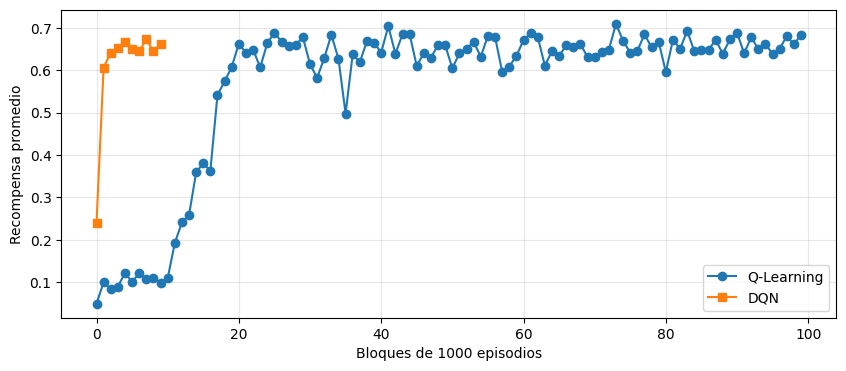

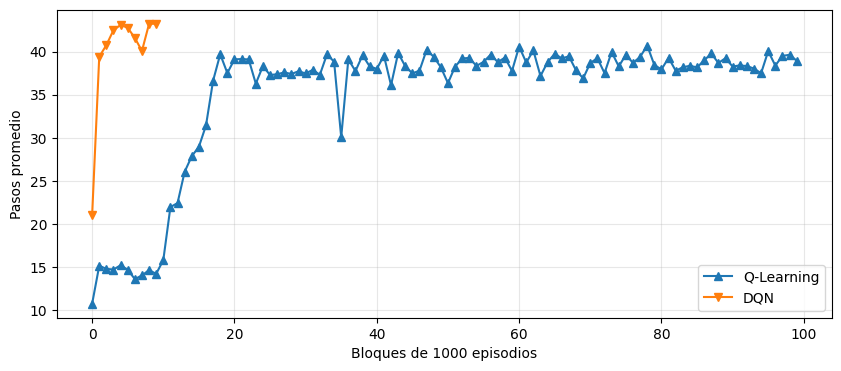

In [ ]:
recompensas_graf_ql = np.array(recompensas_ql)
recompensas_graf_dqn = np.array(recompensas_dqn)
pasos_graf_ql = np.array(l_ql)
pasos_graf_dqn = np.array(l_dqn)

# Calcular promedios por bloques de 1000
def promedios_bloques(recompensas, bloque=1000):
    recompensas = recompensas[:len(recompensas)//bloque * bloque]  # Recortar a múltiplo de 1000
    bloques = recompensas.reshape(-1, bloque)
    return bloques.mean(axis=1)

# Calcular para ambos modelos
recompensas_graf_ql, recompensas_graf_dqn = promedios_bloques(recompensas_graf_ql), promedios_bloques(recompensas_graf_dqn)
pasos_graf_ql, pasos_graf_dqn = promedios_bloques(pasos_graf_ql), promedios_bloques(pasos_graf_dqn)

# Gráfico 1: Recompensas
plt.figure(figsize=(10, 4))
plt.plot(recompensas_graf_ql, 'o-', label='Q-Learning')
plt.plot(recompensas_graf_dqn, 's-', label='DQN')
plt.xlabel('Bloques de 1000 episodios')
plt.ylabel('Recompensa promedio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gráfico 2: Pasos
plt.figure(figsize=(10, 4))
plt.plot(pasos_graf_ql, '^-', label='Q-Learning')
plt.plot(pasos_graf_dqn, 'v-', label='DQN')
plt.xlabel('Bloques de 1000 episodios')
plt.ylabel('Pasos promedio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4.2 Tiempo empleado en entrenar vs Canitad de episodios

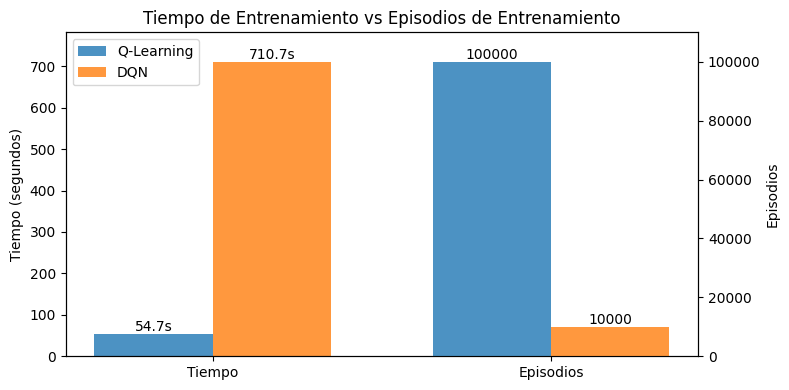

In [31]:
# Gráfica con dos ejes Y
fig, ax1 = plt.subplots(figsize=(8, 4))

# Posiciones de las barras
x = np.arange(2)  # 0: Tiempo, 1: Episodios
ancho = 0.35

# Barras para Q-Learning (eje izquierdo - tiempo)
valores_ql_tiempo = [t_ql_opt, 0]  # Solo tiempo en eje izquierdo
b1_tiempo = ax1.bar(x[0] - ancho/2, t_ql_opt, ancho, label='Q-Learning', alpha=0.8, color='tab:blue')

# Barras para DQN (eje izquierdo - tiempo)
b2_tiempo = ax1.bar(x[0] + ancho/2, t_dqn_opt, ancho, label='DQN', alpha=0.8, color='tab:orange')

ax1.set_ylabel('Tiempo (segundos)', color='black')
ax1.set_ylim(0, max(t_ql_opt, t_dqn_opt) * 1.1)

# Añadir valores en las barras de tiempo
for barra in [b1_tiempo, b2_tiempo]:
    altura = barra[0].get_height()
    ax1.text(barra[0].get_x() + barra[0].get_width()/2, altura, f'{altura:.1f}s',
            ha='center', va='bottom')

# Barras de episodios (eje derecho)
ax2 = ax1.twinx()
b1_episodios = ax2.bar(x[1] - ancho/2, num_episodios_ql, ancho, alpha=0.8, color='tab:blue')
b2_episodios = ax2.bar(x[1] + ancho/2, num_episodios_dqn, ancho, alpha=0.8, color='tab:orange')

ax2.set_ylabel('Episodios', color='black')
ax2.set_ylim(0, max(num_episodios_ql, num_episodios_dqn) * 1.1)

# Añadir valores en las barras de episodios
for barra in [b1_episodios, b2_episodios]:
    altura = barra[0].get_height()
    ax2.text(barra[0].get_x() + barra[0].get_width()/2, altura, f'{int(altura)}',
            ha='center', va='bottom')

# Configuración final
ax1.set_xticks(x)
ax1.set_xticklabels(['Tiempo', 'Episodios'])
ax1.legend(loc='upper left')
ax1.set_title('Tiempo de Entrenamiento vs Episodios de Entrenamiento')
plt.tight_layout()
plt.show()

### 4.3 Comparación de Rendimiento entre Q-Learning y DQN

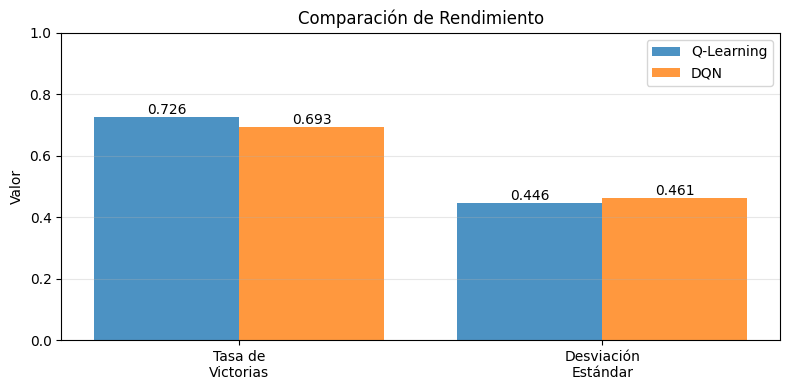

In [30]:
metricas = ['tasa_victorias', 'desv_estandar']
nombres = ['Tasa de\nVictorias', 'Desviación\nEstándar']
valores1 = [resultados_ql[m] for m in metricas]
valores2 = [resultados_dqn[m] for m in metricas]

# Gráfica
x = np.arange(len(metricas))
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - 0.2, valores1, 0.4, label='Q-Learning',alpha=0.8)
b2 = ax.bar(x + 0.2, valores2, 0.4, label='DQN', alpha=0.8)

# Añadir valores en las barras
def añadir_valores(barras):
    for barra in barras:
        altura = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2, altura, f'{altura:.3f}',
                ha='center', va='bottom')

añadir_valores(b1)
añadir_valores(b2)

ax.set_xticks(x)
ax.set_xticklabels(nombres)
ax.set_ylabel('Valor')
ax.set_ylim(0, 1) 
ax.set_title('Comparación de Rendimiento')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## **Extra. Entorno 8x8**

### **Q-Learning**

In [14]:
env = gym.make('FrozenLake-v1',map_name="8x8", is_slippery=True)
agente_ql_8 = AgenteQLearning(env.observation_space.n, env.action_space.n, epsilon_decay=0.0000001)
r, l, p = entrenar_agente_bloques(agente_ql_8, env, num_episodios=150000, max_pasos=300, tam_bloque=15000)

Entrenando 150000 episodios en 10 bloques de 15000
α dinámico: α(s,a) = max(0.03, 1/(25 + visitas))
Bloque 1/10 | tasa_greedy=29.0% | ε=0.9518 | α_prom=0.0304
Bloque 2/10 | tasa_greedy=55.4% | ε=0.9009 | α_prom=0.0302
Bloque 3/10 | tasa_greedy=60.8% | ε=0.8474 | α_prom=0.0301
Bloque 4/10 | tasa_greedy=48.4% | ε=0.7911 | α_prom=0.0300
Bloque 5/10 | tasa_greedy=52.0% | ε=0.7321 | α_prom=0.0300
Bloque 6/10 | tasa_greedy=63.1% | ε=0.6696 | α_prom=0.0300
Bloque 7/10 | tasa_greedy=54.9% | ε=0.6033 | α_prom=0.0300
Bloque 8/10 | tasa_greedy=63.1% | ε=0.5337 | α_prom=0.0300
Bloque 9/10 | tasa_greedy=56.7% | ε=0.4598 | α_prom=0.0300
Bloque 10/10 | tasa_greedy=54.4% | ε=0.3815 | α_prom=0.0300


In [15]:
resultados_ql_8 = evaluar_agente_custom(agente_ql_8, env, num_episodios=5000)
imprimir_resultados_evaluacion(resultados_ql_8, "Agente Q-Learning - mejores hiperparámetros")
agente_ql_8.mostrar_política()


Agente Q-Learning - mejores hiperparámetros - Resultados de Evaluación:
Tasa de Victorias: 60.8%
Recompensa Promedio: 0.608
Desviación Estándar: 0.488
Total de Victorias: 3039
[['↑' '→' '→' '→' '→' '→' '→' '→']
 ['↑' '↑' '↑' '↑' '↑' '→' '→' '↓']
 ['↑' '↑' '←' '←' '→' '↑' '→' '↓']
 ['↑' '↑' '↑' '↑' '←' '←' '→' '↓']
 ['↑' '↑' '←' '←' '→' '↓' '↑' '→']
 ['←' '←' '←' '→' '↑' '←' '←' '→']
 ['←' '←' '↓' '←' '←' '→' '←' '→']
 ['←' '↓' '↓' '←' '→' '↓' '↓' '←']]


### **DQN**

In [21]:
env = gym.make('FrozenLake-v1',map_name="8x8", is_slippery=True)
agente_dqn_8 = AgenteDQN(env.observation_space.n, env.action_space.n, memoria_max=20000, batch_size=128, lr=0.0001, gamma=0.99, epsilon_decay=0.999, epsilon_min=0.01)
r, l = entrenar_agente(agente_dqn_8, env, num_episodios=20000, max_pasos=150)

Episodio 2000: Recompensa Promedio = 0.108, Longitud Promedio = 49.3
Episodio 4000: Recompensa Promedio = 0.400, Longitud Promedio = 70.3
Episodio 6000: Recompensa Promedio = 0.521, Longitud Promedio = 73.4
Episodio 8000: Recompensa Promedio = 0.529, Longitud Promedio = 74.8
Episodio 10000: Recompensa Promedio = 0.520, Longitud Promedio = 74.5
Episodio 12000: Recompensa Promedio = 0.516, Longitud Promedio = 73.7
Episodio 14000: Recompensa Promedio = 0.543, Longitud Promedio = 73.6
Episodio 16000: Recompensa Promedio = 0.525, Longitud Promedio = 73.4
Episodio 18000: Recompensa Promedio = 0.543, Longitud Promedio = 73.9
Episodio 20000: Recompensa Promedio = 0.557, Longitud Promedio = 71.3


In [22]:
resultados_dqn_8 = evaluar_agente_custom(agente_dqn_8, env, num_episodios=5000)
imprimir_resultados_evaluacion(resultados_dqn_8, "Agente Q-Learning - mejores hiperparámetros")
agente_dqn_8.mostrar_política()


Agente Q-Learning - mejores hiperparámetros - Resultados de Evaluación:
Tasa de Victorias: 52.5%
Recompensa Promedio: 0.525
Desviación Estándar: 0.499
Total de Victorias: 2623
[['↑' '↑' '→' '→' '→' '→' '→' '→']
 ['↑' '↑' '↑' '↑' '↑' '→' '→' '↓']
 ['↑' '→' '↑' '→' '→' '←' '→' '↓']
 ['→' '←' '←' '↑' '←' '→' '→' '→']
 ['↑' '↑' '↑' '←' '→' '↓' '↑' '→']
 ['←' '→' '→' '↑' '↑' '←' '→' '→']
 ['↑' '→' '↓' '↑' '→' '←' '→' '→']
 ['↑' '↑' '↓' '→' '↑' '→' '↓' '→']]


## **Extra. Q-Learning con repetición de episodios**

In [25]:
class AgenteQLearningConReplay(Agente):
    """Agente Q-Learning con Experience Replay."""

    def __init__(self, action_space, cant_estados=16, replay_size=1000, replay_episodios=5, umbral_exito=1000, num_episodios=2000):
        self.q_table = np.zeros((cant_estados, 4), dtype=np.float64)
        self.q_visitas = np.zeros((cant_estados, 4), dtype=np.int32)
        self.action_space = action_space.n
        self.epsilon = 1
        self.cont_episodios = 0
        self.umbral_exito = umbral_exito

        # Buffer de experiencias
        self.replay_buffer = deque(maxlen=replay_size)
        self.episodios_exitosos = deque(maxlen=500)  # Buffer episodios exitosos
        self.replay_episodios = replay_episodios # Veces que se repite cada episodio
        self.episodio_actual = []
        
        # Configuración según tamaño del estado
        if cant_estados == 16:
            self.epsilon_min = 0.01
            self.epsilon_decay = self.epsilon_min ** (1 / (num_episodios * 0.9))
            self.gamma = 0.99
            self.alpha_min = 0.1
        elif cant_estados == 64:
            self.epsilon_decay = 0.9994
            self.epsilon_min = 0.01
            self.gamma = 0.99
            self.alpha_min = 0.05
    
    def elegir_accion(self, estado):
        """Elige una acción usando política epsilon-greedy."""
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_space)
        else:
            return np.argmax(self.q_table[estado])

    def aprender(self, estado, accion, recompensa, siguiente_estado, terminado):
        """Almacena la experiencia y aprende cuando termina el episodio."""
        # Guardar transición en el episodio actual
        self.episodio_actual.append((estado, accion, recompensa, siguiente_estado, terminado))
        
        if terminado:
            self.cont_episodios += 1
            episodio_completo = list(self.episodio_actual)
            # Guardar episodio completo en el buffer
            self.replay_buffer.append(episodio_completo)

            es_exitoso = recompensa > 0
            if es_exitoso:
                self.episodios_exitosos.append(episodio_completo)
            
            # Una vez para actualziar visitas
            self._actualizar_q_desde_episodio(episodio_completo, incrementar_visitas=True)
            # Repetir el episodio actual
            for _ in range(self.replay_episodios - 1):
                self._actualizar_q_desde_episodio(episodio_completo)
            
            # Replay de episodios exitosos
            if len(self.episodios_exitosos) > 0:
                num_replays_exitosos = min(5, len(self.episodios_exitosos)) # Maximo 5 episodios exitosos
                for _ in range(num_replays_exitosos):
                    episodio_replay = random.choice(self.episodios_exitosos)
                    self._actualizar_q_desde_episodio(episodio_replay)
            
            # Replay de episodios normales (menos frecuente)
            if len(self.replay_buffer) > 10:
                num_replays_normales = 2
                for _ in range(num_replays_normales):
                    episodio_replay = random.choice(self.replay_buffer)
                    self._actualizar_q_desde_episodio(episodio_replay)

            # Limpiar episodio actual
            self.episodio_actual = []
            
            # Decrementar epsilon
            if self.full_exploracion() == False and self.epsilon > self.epsilon_min:
                self.epsilon *= self.epsilon_decay
    
    def _actualizar_q_desde_episodio(self, episodio, incrementar_visitas=False):
        """Actualiza la tabla Q usando todas las transiciones de un episodio."""
        for estado, accion, recompensa, siguiente_estado, terminado in episodio:
            # Calcular Q actual
            qActual = self.q_table[estado, accion]
            
            if incrementar_visitas:
                self.q_visitas[estado, accion] += 1
            alpha = 1.0 / (1.0 +self.q_visitas[estado, accion])
            alpha = max(alpha, self.alpha_min)
            
            # Calcular target
            if terminado:
                maxQ = 0
            else:
                maxQ = np.max(self.q_table[siguiente_estado])
            
            # Actualizar Q-table
            self.q_table[estado, accion] = (1 - alpha) * qActual + alpha * (recompensa + self.gamma * maxQ)

    def full_exploracion(self):
        return (len(self.episodios_exitosos) == 0 and self.cont_episodios < self.umbral_exito)
    
    def mostrar_política(self):
        """Muestra la política aprendida por el agente DQN."""
        acciones_mapa = {0: '←', 1: '↓', 2: '→', 3: '↑'}
        politica = np.array([acciones_mapa[int(np.argmax(self.q_table[s, :]))] 
                          for s in range(self.q_table.shape[0])]).reshape(int(np.sqrt(self.q_table.shape[0])), int(np.sqrt(self.q_table.shape[0])))
        print(politica)

In [26]:
num_episodios = 10000

# Entrenar agente con Experience Replay
env = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=True)
agente_replay = AgenteQLearningConReplay(
    env.action_space, 
    cant_estados=16,
    replay_size=500,      # Tamaño del buffer
    replay_episodios=5,     # Veces que se repite cada episodio
    umbral_exito=1000,
    num_episodios=num_episodios
)

print("Entrenando con Experience Replay.")
t_start = time.time()
entrenar_agente(agente_replay, env, num_episodios=num_episodios, max_pasos=100)
t_end = time.time() 
print(f"Tiempo de entrenamiento: {t_end - t_start:.2f} segundos")
# Evaluar
agente_replay.epsilon = 0.0
resultados = evaluar_agente(agente_replay, env, num_episodios=1000)
imprimir_resultados_evaluacion(resultados, "Agente Q-Learning con Replay")
agente_replay.mostrar_política()
env.close()

Entrenando con Experience Replay.
Episodio 1000: Recompensa Promedio = 0.022, Longitud Promedio = 9.0
Episodio 2000: Recompensa Promedio = 0.054, Longitud Promedio = 12.0
Episodio 3000: Recompensa Promedio = 0.129, Longitud Promedio = 16.2
Episodio 4000: Recompensa Promedio = 0.189, Longitud Promedio = 20.2
Episodio 5000: Recompensa Promedio = 0.284, Longitud Promedio = 26.7
Episodio 6000: Recompensa Promedio = 0.380, Longitud Promedio = 31.3
Episodio 7000: Recompensa Promedio = 0.436, Longitud Promedio = 35.3
Episodio 8000: Recompensa Promedio = 0.456, Longitud Promedio = 38.8
Episodio 9000: Recompensa Promedio = 0.550, Longitud Promedio = 41.1
Episodio 10000: Recompensa Promedio = 0.576, Longitud Promedio = 40.5
Tiempo de entrenamiento: 14.80 segundos

Agente Q-Learning con Replay - Resultados de Evaluación:
Tasa de Victorias: 62.1%
Recompensa Promedio: 0.621
Desviación Estándar: 0.485
Total de Victorias: 621
[['←' '↑' '↑' '↑']
 ['←' '←' '→' '←']
 ['↑' '↓' '↓' '←']
 ['←' '→' '↓' '←']